In [33]:
import pandas as pd 
import numpy as np 
from rdkit import Chem
import torch
from torch_geometric.data import Data 
from torch_geometric.loader import DataLoader
import networkx as nx
import matplotlib.pyplot as plt

In [6]:
qm8=pd.read_csv("C:\\Users\\kolhe\\gnn\\Molecular-Property-Prediction-Using-GNN-and-Transformer\\Dataset\\qm8.csv")


In [7]:
qm9=pd.read_csv("C:\\Users\\kolhe\\gnn\\Molecular-Property-Prediction-Using-GNN-and-Transformer\\Dataset\\qm9.csv")

In [8]:
print(qm8.shape)
print(qm9.shape)

(21786, 17)
(133885, 21)


In [9]:
#checking for hidden missing values
empty_smiles = (qm9['smiles'].str.strip() == "").sum()
print(empty_smiles)

0


In [10]:
qm8.tail()

,smiles,E1-CC2,E2-CC2,f1-CC2,f2-CC2,E1-PBE0,E2-PBE0,f1-PBE0,f2-PBE0,E1-PBE0.1,E2-PBE0.1,f1-PBE0.1,f2-PBE0.1,E1-CAM,E2-CAM,f1-CAM,f2-CAM
21781,[H]C([H])(N1C([H])([H])C1([H])[H])C(F)(F)F,0.271951,0.297488,0.049481,0.039746,0.279686,0.305949,0.045505,0.036458,0.279686,0.305949,0.045505,0.036458,0.276414,0.297798,0.0314,0.0409
21782,[H]C1([H])C([H])([H])C([H])(C(F)(F)F)C1([H])[H],0.343606,0.344621,0.044959,0.017041,0.347063,0.348212,0.003887,0.057040,0.347063,0.348212,0.003887,0.057040,0.336025,0.337881,0.0376,0.0107
21783,[H]N1C([H])([H])C([H])([H])C1([H])C(F)(F)F,0.256356,0.279425,0.005103,0.010683,0.264920,0.280065,0.002531,0.009899,0.264920,0.280065,0.002531,0.009899,0.253210,0.279390,0.0037,0.0086
21784,[H]C1([H])OC([H])(C(F)(F)F)C1([H])[H],0.271197,0.292573,0.000831,0.019204,0.279916,0.302611,0.000742,0.022324,0.279916,0.302611,0.000742,0.022324,0.274602,0.299852,0.0004,0.0195
21785,[H]C1([H])OC([H])([H])C1([H])C(F)(F)F,0.262279,0.284981,0.000044,0.024138,0.276903,0.292604,0.001943,0.023766,0.276903,0.292604,0.001943,0.023766,0.266829,0.292043,0.0001,0.0266


In [11]:
qm9.tail()

,mol_id,smiles,A,B,C,mu,alpha,homo,lumo,gap,...,zpve,u0,u298,h298,g298,cv,u0_atom,u298_atom,h298_atom,g298_atom
133880,gdb_133881,C1C2C3C4C5OC14C5N23,3.59483,2.19899,1.90423,1.6637,69.37,-0.2254,0.0588,0.2842,...,0.127406,-400.633868,-400.628599,-400.627654,-400.663098,23.658,-1603.983913,-1614.898804,-1623.788097,-1492.819438
133881,gdb_133882,C1N2C3C2C2C4OC12C34,3.65648,2.14237,1.90439,1.2976,69.52,-0.2393,0.0608,0.3002,...,0.127495,-400.629713,-400.624444,-400.623500,-400.658942,23.697,-1601.376613,-1612.291504,-1621.181424,-1490.211511
133882,gdb_133883,C1N2C3C4C5C2C13CN45,3.67118,2.14314,1.89501,1.2480,73.60,-0.2233,0.0720,0.2953,...,0.140458,-380.753918,-380.748619,-380.747675,-380.783148,23.972,-1667.045429,-1678.830048,-1688.312964,-1549.143391
133883,gdb_133884,C1N2C3C4C5CC13C2C45,3.52845,2.15131,1.86582,1.9576,77.40,-0.2122,0.0881,0.3003,...,0.152222,-364.720374,-364.714974,-364.714030,-364.749650,24.796,-1794.600439,-1807.210860,-1817.286772,-1670.349892
133884,gdb_133885,C1N2C3C4C5OC13C2C45,3.64015,2.21764,1.93793,0.8626,69.48,-0.2316,0.0742,0.3058,...,0.127862,-400.633052,-400.627892,-400.626948,-400.662186,23.434,-1603.471865,-1614.455155,-1623.345075,-1492.247150


In [12]:
qm8.isnull().sum()

smiles       0
E1-CC2       0
E2-CC2       0
f1-CC2       0
f2-CC2       0
E1-PBE0      0
E2-PBE0      0
f1-PBE0      0
f2-PBE0      0
E1-PBE0.1    0
E2-PBE0.1    0
f1-PBE0.1    0
f2-PBE0.1    0
E1-CAM       0
E2-CAM       0
f1-CAM       0
f2-CAM       0
dtype: int64

In [13]:
qm9.isnull().sum()

mol_id       0
smiles       0
A            0
B            0
C            0
mu           0
alpha        0
homo         0
lumo         0
gap          0
r2           0
zpve         0
u0           0
u298         0
h298         0
g298         0
cv           0
u0_atom      0
u298_atom    0
h298_atom    0
g298_atom    0
dtype: int64

In [14]:
'''Canonicalizing smilies - since the smiles in both qm8 nd qm9 are
 in different format we have to change it to a standard format so that
 one molecule should not be treated as two  different molecules'''

'Canonicalizing smilies - since the smiles in both qm8 nd qm9 are\n in different format we have to change it to a standard format so that\n one molecule should not be treated as two  different molecules'

In [15]:
def canonicalize(smiles):
    return Chem.MolToSmiles(Chem.MolFromSmiles(smiles))

qm8['smiles_new'] = qm8['smiles'].apply(canonicalize)
qm9['smiles_new'] = qm9['smiles'].apply(canonicalize)

In [16]:
qm8.head(3)

,smiles,E1-CC2,E2-CC2,f1-CC2,f2-CC2,E1-PBE0,E2-PBE0,f1-PBE0,f2-PBE0,E1-PBE0.1,E2-PBE0.1,f1-PBE0.1,f2-PBE0.1,E1-CAM,E2-CAM,f1-CAM,f2-CAM,smiles_new
0,[H]C([H])([H])[H],0.432952,0.432960,0.249728,0.249736,0.430218,0.430236,0.181436,1.815015e-01,0.430218,0.430236,0.181436,1.815015e-01,0.409931,0.409939,0.1832,0.1832,C
1,[H]N([H])[H],0.265220,0.350081,0.067015,0.030049,0.268386,0.349106,0.040761,3.164115e-02,0.268386,0.349106,0.040761,3.164115e-02,0.253853,0.334481,0.0575,0.0238,N
2,[H]O[H],0.286537,0.363579,0.037755,0.000000,0.291377,0.362091,0.019503,1.000000e-08,0.291377,0.362091,0.019503,1.000000e-08,0.278519,0.350074,0.0333,0.0000,O


In [17]:
qm9.head(3)

,mol_id,smiles,A,B,C,mu,alpha,homo,lumo,gap,...,u0,u298,h298,g298,cv,u0_atom,u298_atom,h298_atom,g298_atom,smiles_new
0,gdb_1,C,157.71180,157.70997,157.70699,0.0000,13.21,-0.3877,0.1171,0.5048,...,-40.478930,-40.476062,-40.475117,-40.498597,6.469,-395.999595,-398.643290,-401.014647,-372.471772,C
1,gdb_2,N,293.60975,293.54111,191.39397,1.6256,9.46,-0.2570,0.0829,0.3399,...,-56.525887,-56.523026,-56.522082,-56.544961,6.316,-276.861363,-278.620271,-280.399259,-259.338802,N
2,gdb_3,O,799.58812,437.90386,282.94545,1.8511,6.31,-0.2928,0.0687,0.3615,...,-76.404702,-76.401867,-76.400922,-76.422349,6.002,-213.087624,-213.974294,-215.159658,-201.407171,O


In [18]:
#full outter join to merge both the data
df = pd.merge(qm8, qm9, on='smiles_new', how='outer')

In [19]:
df.shape

(133925, 39)

In [20]:
df.head(3)

,smiles_x,E1-CC2,E2-CC2,f1-CC2,f2-CC2,E1-PBE0,E2-PBE0,f1-PBE0,f2-PBE0,E1-PBE0.1,...,zpve,u0,u298,h298,g298,cv,u0_atom,u298_atom,h298_atom,g298_atom
0,[H]C([H])([H])[H],0.432952,0.432960,0.249728,0.249736,0.430218,0.430236,0.181436,0.181502,0.430218,...,0.044749,-40.478930,-40.476062,-40.475117,-40.498597,6.469,-395.999595,-398.643290,-401.014647,-372.471772
1,[H]C#C[H],0.358629,0.358629,0.000000,0.000000,0.256321,0.268469,0.000000,0.000000,0.256321,...,0.026841,-77.308427,-77.305527,-77.304583,-77.327429,8.574,-385.501997,-387.237686,-389.016047,-365.800724
2,[H]C#CC([H])([H])[H],0.273389,0.285750,0.000000,0.001194,0.251415,0.262750,0.000000,0.001653,0.251415,...,0.055410,-116.609549,-116.605550,-116.604606,-116.633775,12.482,-670.268091,-673.980434,-677.537155,-631.346845


In [21]:
df.isnull().sum()

smiles_x      112099
E1-CC2        112099
E2-CC2        112099
f1-CC2        112099
f2-CC2        112099
E1-PBE0       112099
E2-PBE0       112099
f1-PBE0       112099
f2-PBE0       112099
E1-PBE0.1     112099
E2-PBE0.1     112099
f1-PBE0.1     112099
f2-PBE0.1     112099
E1-CAM        112099
E2-CAM        112099
f1-CAM        112099
f2-CAM        112099
smiles_new         0
mol_id             0
smiles_y           0
A                  0
B                  0
C                  0
mu                 0
alpha              0
homo               0
lumo               0
gap                0
r2                 0
zpve               0
u0                 0
u298               0
h298               0
g298               0
cv                 0
u0_atom            0
u298_atom          0
h298_atom          0
g298_atom          0
dtype: int64

In [22]:
target_columns = ['E1-CC2', 'E2-CC2', 'f1-CC2', 'f2-CC2', 'A', 'B', 'C', 'mu', 'alpha', 'homo', 'lumo', 'gap'] 
# We fill NaNs with 0 temporarily to avoid math error 
Y = df[target_columns].fillna(0).values
# but the MASK will tell the model to ignore these 0 since we are filling 1 at places where data exists.
Mask = df[target_columns].notna().astype(int).values
print(f"Target Shape: {Y.shape}")
print(f"Mask Shape: {Mask.shape}")

Target Shape: (133925, 12)
Mask Shape: (133925, 12)


In [23]:
''' we are using mask to avoid errors during loss calculation so here's what we have done:-
1)replaced Nans with 0
2)made a matrix named mask with boolen values so that the model knows which values are true and which values were nans (now replaced by 0)
3)during loss calculation we will multiply the loss by the feature's mask value so if the value is 1 the actual value will remain same
but if it is 0 the value will be replaced by 0, in this way the model will understand this is not the actual value and it was replaced by 0
earlier.
4)read the whole code not just the comments to actually understand the logic behind this.
'''

" we are using mask to avoid errors during loss calculation so here's what we have done:-\n1)replaced Nans with 0\n2)made a matrix named mask with boolen values so that the model knows which values are true and which values were nans (now replaced by 0)\n3)during loss calculation we will multiply the loss by the feature's mask value so if the value is 1 the actual value will remain same\nbut if it is 0 the value will be replaced by 0, in this way the model will understand this is not the actual value and it was replaced by 0\nearlier.\n4)read the whole code not just the comments to actually understand the logic behind this.\n"

In [24]:
# Convert to DataFrame just to see and verify
y_check = pd.DataFrame(Y, columns=target_columns)
mask_check = pd.DataFrame(Mask, columns=target_columns)

In [25]:
y_check.head()

,E1-CC2,E2-CC2,f1-CC2,f2-CC2,A,B,C,mu,alpha,homo,lumo,gap
0,0.432952,0.432960,0.249728,0.249736,157.71180,157.709970,157.706990,0.0000,13.21,-0.3877,0.1171,0.5048
1,0.358629,0.358629,0.000000,0.000000,0.00000,35.610036,35.610036,0.0000,16.28,-0.2845,0.0506,0.3351
2,0.273389,0.285750,0.000000,0.001194,160.28041,8.593230,8.593210,0.7156,28.78,-0.2609,0.0613,0.3222
3,0.205525,0.214674,0.000000,0.000000,0.00000,4.425973,4.425973,0.0000,38.52,-0.2599,-0.0214,0.2386
4,0.204037,0.212709,0.000000,0.000248,160.02654,2.048960,2.048960,1.1881,54.54,-0.2420,-0.0085,0.2335


In [26]:
"""
TARGET FEATURE DESCRIPTIONS:
--- QM8 (Electronic Properties / Excited States) ---
E1-CC2:   First electronic excitation energy (how much energy to move an electron to its first 'jump').
E2-CC2:   Second electronic excitation energy (energy for the second-level 'jump').
f1-CC2:   Oscillator strength of the first jump (how likely/bright the transition is).
f2-CC2:   Oscillator strength of the second jump (intensity of the second transition).
*Note: 'CC2' refers to the high-level quantum chemistry method used for these calculations.*

--- QM9 (Geometric & Thermodynamic Properties) ---
A, B, C:  Rotational constants. They define how the molecule's mass is distributed and how it spins.
mu:       Dipole moment. Measures the 'magnet-like' polarity of the molecule.
alpha:    Isotropic polarizability. How easily the electron cloud can be 'squished' by an external field.
homo:     Highest Occupied Molecular Orbital. The energy of the outermost 'full' electron layer.
lumo:     Lowest Unoccupied Molecular Orbital. The energy of the first available 'empty' electron layer.
gap:      The Energy Gap (LUMO minus HOMO). Determines if the molecule is a conductor or insulator.
"""

"\nTARGET FEATURE DESCRIPTIONS:\n--- QM8 (Electronic Properties / Excited States) ---\nE1-CC2:   First electronic excitation energy (how much energy to move an electron to its first 'jump').\nE2-CC2:   Second electronic excitation energy (energy for the second-level 'jump').\nf1-CC2:   Oscillator strength of the first jump (how likely/bright the transition is).\nf2-CC2:   Oscillator strength of the second jump (intensity of the second transition).\n*Note: 'CC2' refers to the high-level quantum chemistry method used for these calculations.*\n\n--- QM9 (Geometric & Thermodynamic Properties) ---\nA, B, C:  Rotational constants. They define how the molecule's mass is distributed and how it spins.\nmu:       Dipole moment. Measures the 'magnet-like' polarity of the molecule.\nalpha:    Isotropic polarizability. How easily the electron cloud can be 'squished' by an external field.\nhomo:     Highest Occupied Molecular Orbital. The energy of the outermost 'full' electron layer.\nlumo:     Low

In [27]:
# dataset
sample_df = df.sample(n=50, random_state=42).reset_index(drop=True)
# Extracting the Y and Mask for just these 50 rows
sample_Y = torch.tensor(Y[sample_df.index], dtype=torch.float32)
sample_Mask = torch.tensor(Mask[sample_df.index], dtype=torch.float32)
sample_df.shape

(50, 39)

In [28]:
#class and object form of the same code (still working  on it)
class MoleculeDataPipeline:
    def __init__(self, qm8_path, qm9_path):
        self.qm8_path = "C:\\Users\\kolhe\\gnn\\Molecular-Property-Prediction-Using-GNN-and-Transformer\\Dataset\\qm8.csv"
        self.qm9_path = "C:\\Users\\kolhe\\gnn\\Molecular-Property-Prediction-Using-GNN-and-Transformer\\Dataset\\qm9.csv"
        self.df = None
        self.Y = None
        self.mask = None

    def _canonicalize(self, smiles):
        #standardizes SMILES strings 
        mol = Chem.MolFromSmiles(smiles)
        return Chem.MolToSmiles(mol) if mol else None

    def process_and_merge(self):
        #load data
        df8 = pd.read_csv(self.qm8_path)
        df9 = pd.read_csv(self.qm9_path)

        #Canonicalize SMILES for both
        df8['smiles_new'] = df8['smiles'].apply(self._canonicalize)
        df9['smiles_new'] = df9['smiles'].apply(self._canonicalize)

        # Outer Join (merge)
        self.master_df = pd.merge(df8, df9, on='smiles_new', how='outer')
        
        # 12 Property Columns
        target_cols = ['E1-CC2', 'E2-CC2', 'f1-CC2', 'f2-CC2', # qm8
                       'mu', 'alpha', 'homo', 'lumo', 'gap', 'r2', 'zpve', 'u0'] #qm9
        
        #Create mask and Y
        data_subset = self.master_df[target_cols]
        self.mask = data_subset.notna().astype(int).values
        self.Y = data_subset.fillna(0).values
        
        print(f"Pipeline Complete: {len(self.master_df)} total molecules processed.")
        return self.master_df, self.Y, self.mask

In [29]:
#testing the pipeline with sample dataset 
#sample data of 500 molecules
sample_df = df.sample(n=500, random_state=42).reset_index(drop=True)
target_cols = ['E1-CC2', 'E2-CC2', 'f1-CC2', 'f2-CC2', 'mu', 'alpha', 'homo', 'lumo', 'gap', 'r2', 'zpve', 'u0']

#Y and Mask arrays for the sample
sample_Y = sample_df[target_cols].fillna(0).values
sample_Mask = sample_df[target_cols].notna().astype(int).values

#Convert them to PyTorch Tensors
y_tensor = torch.tensor(sample_Y, dtype=torch.float32)
mask_tensor = torch.tensor(sample_Mask, dtype=torch.float32)
print(sample_df.head())

               smiles_x    E1-CC2    E2-CC2    f1-CC2    f2-CC2   E1-PBE0  \
0                   NaN       NaN       NaN       NaN       NaN       NaN   
1                   NaN       NaN       NaN       NaN       NaN       NaN   
2  [H]N=c1onnc(=O)n1[H]  0.148305  0.162574  0.003622  0.005138  0.133259   
3                   NaN       NaN       NaN       NaN       NaN       NaN   
4                   NaN       NaN       NaN       NaN       NaN       NaN   

    E2-PBE0   f1-PBE0   f2-PBE0  E1-PBE0.1  ...      zpve          u0  \
0       NaN       NaN       NaN        NaN  ...  0.136266 -384.562159   
1       NaN       NaN       NaN        NaN  ...  0.110332 -548.234361   
2  0.148686  0.003103  0.000068   0.133259  ...  0.059717 -446.755759   
3       NaN       NaN       NaN        NaN  ...  0.180310 -424.185610   
4       NaN       NaN       NaN        NaN  ...  0.184723 -424.239876   

         u298        h298        g298      cv      u0_atom    u298_atom  \
0 -384.555552 -384.5546

In [30]:
def smiles_to_graph_advanced(smiles, y_values, mask_values):
    #Convert SMILES to RDKit Molecule
    mol = Chem.MolFromSmiles(smiles)
    if not mol:
        return None

    #Extract 6 Advanced Node Features
    node_feats = []
    for atom in mol.GetAtoms():
        node_feats.append([
            atom.GetAtomicNum(),         # Identity 
            atom.GetDegree(),            # no of neighnours
            atom.GetFormalCharge(),      # Electronic state
            atom.GetTotalNumHs(),        # Hydrogen bonding potential
            int(atom.GetIsAromatic()),   # Structural stability
            int(atom.GetHybridization()) # Geometry (sp, sp2, sp3)
        ])
    x = torch.tensor(node_feats, dtype=torch.float)

    #Extract Edge Indices (Bonds)
    edges = []
    for bond in mol.GetBonds():
        i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        edges.append([i, j])
        edges.append([j, i]) # Bidirectional
    edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()

    #Targets and Mask (Reshaped to [1, 12] for perfect batching)
    y = y_values.clone().detach().view(1, -1)
    mask = mask_values.clone().detach().view(1, -1)

    return Data(x=x, edge_index=edge_index, y=y, mask=mask)

In [31]:
sample_graphs = []

for i in range(len(sample_df)):
    smiles = sample_df['smiles_new'].iloc[i]
    y_val = y_tensor[i]
    mask_val = mask_tensor[i]
    
    #Generate graph
    graph = smiles_to_graph_advanced(smiles, y_val, mask_val)
    
    if graph:
        sample_graphs.append(graph)

# Create the final DataLoader
# This is what you will use for the model training
train_loader = DataLoader(sample_graphs, batch_size=32, shuffle=True)

print(f"Successfully processed {len(sample_graphs)} molecules.")
print(f"Input features per atom: {sample_graphs[0].num_node_features}")

Successfully processed 500 molecules.
Input features per atom: 6


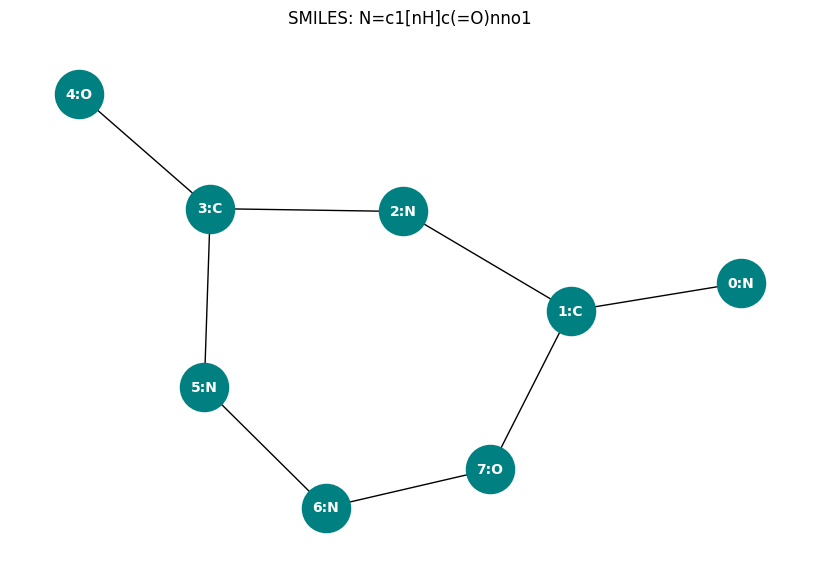

In [37]:
import networkx as nx
import matplotlib.pyplot as plt
from rdkit import Chem

def plot_simple_molecule(index):
    # Get the data from your prepared lists
    data = sample_graphs[index]
    smiles = sample_df['smiles_new'].iloc[index]
    
    # Create the Graph
    G = nx.Graph()
    
    # Create Labels: "Index: Symbol" (e.g., "0:C")
    node_labels = {}
    for i in range(data.num_nodes):
        atomic_num = int(data.x[i][0]) # Get atomic number from first feature
        symbol = Chem.GetPeriodicTable().GetElementSymbol(atomic_num)
        node_labels[i] = f"{i}:{symbol}"
        G.add_node(i)

    # Add Edges
    edge_list = data.edge_index.t().tolist()
    G.add_edges_from(edge_list)

    # Plotting
    plt.figure(figsize=(8, 5))
    pos = nx.spring_layout(G, seed=42) # Keeps the shape consistent
    
    nx.draw(G, pos, with_labels=True, labels=node_labels, 
            node_color='teal', node_size=1200, 
            font_color='white', font_weight='bold', font_size=10)
    
    plt.title(f"SMILES: {smiles}", fontsize=12, pad=20)
    plt.show()

# Visualize the first molecule
plot_simple_molecule(2)

In [41]:
# Grab the very first batch
batch = next(iter(train_loader))

print("--- Batch Overview ---")
print(f"Number of molecules in this batch: {batch.num_graphs}")
print(f"Total atoms in this batch: {batch.x.shape[0]}")
print(f"Features per atom: {batch.num_node_features}")
print(f"Targets shape: {batch.y.shape} (Should be [32, 12])")
print(f"Mask shape: {batch.mask.shape} (Should be [32, 12])")

# See the 'batch' vector that separates the molecules
print(f"First 20 elements of batch vector: {batch.batch[:20]}")

--- Batch Overview ---
Number of molecules in this batch: 32
Total atoms in this batch: 285
Features per atom: 6
Targets shape: torch.Size([32, 12]) (Should be [32, 12])
Mask shape: torch.Size([32, 12]) (Should be [32, 12])
First 20 elements of batch vector: tensor([0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2])
